# Dataset decription

The Intel Image Classification dataset is used in this project for a multi-class image classification task. It contains natural scene images organised into 6 categories:

- Buildings — images of urban structures and architecture

- Forest — dense trees and natural woodland areas

- Glacier — icy and snow-covered landscapes

- Mountain — rocky elevated terrain and mountain ranges

- Sea — ocean and coastal water scenes

- Street — urban roads and city views

###Key Details:

- Training images: ~14,000 (split into 80% train, 20% validation)

- Test images: ~3,000

- Number of classes: 6

- Image size: resized to 128×128 pixels for training

- Batch size: 32

- Source: Kaggle — Intel Image Classification

The dataset is loaded using ImageDataGenerator with flow_from_directory(), with data augmentation applied on training data (rotation, zoom, horizontal flip, width and height shift) and only rescaling applied on validation and test data. The dataset is used to train, compare and evaluate CNN models from scratch as well as a fine-tuned MobileNetV2 transfer learning model.

##Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import time

##Mount Drive & Set Dataset Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ✅ FIXED: Point directly to seg_train and seg_test folders
train_path = "/content/drive/MyDrive/Dataset/ML_AI/Intel Image Classification/seg_train/seg_train"
test_path  = "/content/drive/MyDrive/Dataset/ML_AI/Intel Image Classification/seg_test/seg_test"

print("Classes in train:", os.listdir(train_path))
print("Classes in test: ", os.listdir(test_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes in train: ['glacier', 'forest', 'mountain', 'sea', 'street', 'buildings']
Classes in test:  ['buildings', 'forest', 'mountain', 'glacier', 'street', 'sea']


##Data Preprocessing + Augmentation

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# ✅ FIXED: Augmentation ONLY on training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# ✅ FIXED: Validation gets ONLY rescaling — no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Separate test generator for final evaluation
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print("Number of classes:", num_classes)
print("Classes:", class_names)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training samples: 11230
Validation samples: 2804
Test samples: 3000


##Dataset Analysis: Class Distribution

Class Distribution:
  buildings: 2191 images
  forest: 2271 images
  glacier: 2404 images
  mountain: 2512 images
  sea: 2274 images
  street: 2382 images


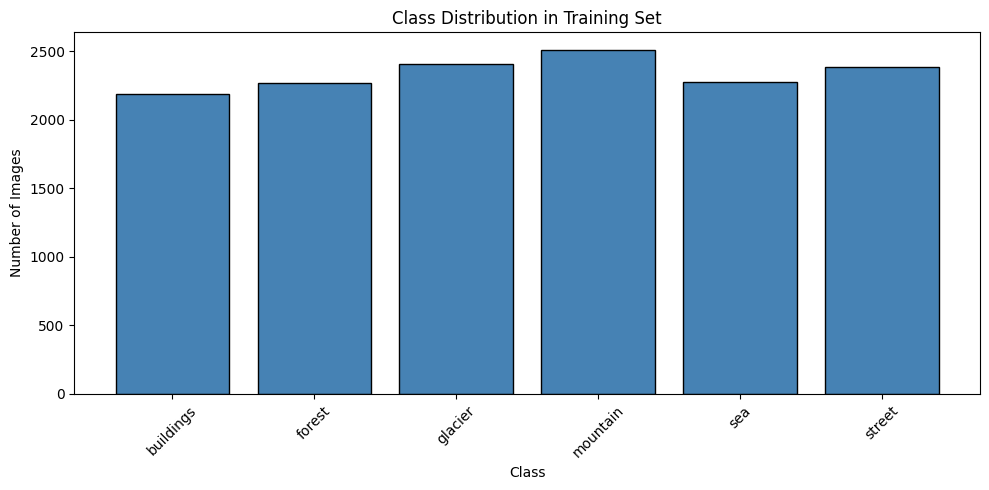

In [ ]:
# Count images per class
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(train_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count} images")

# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Visualize Sample Images Per Class

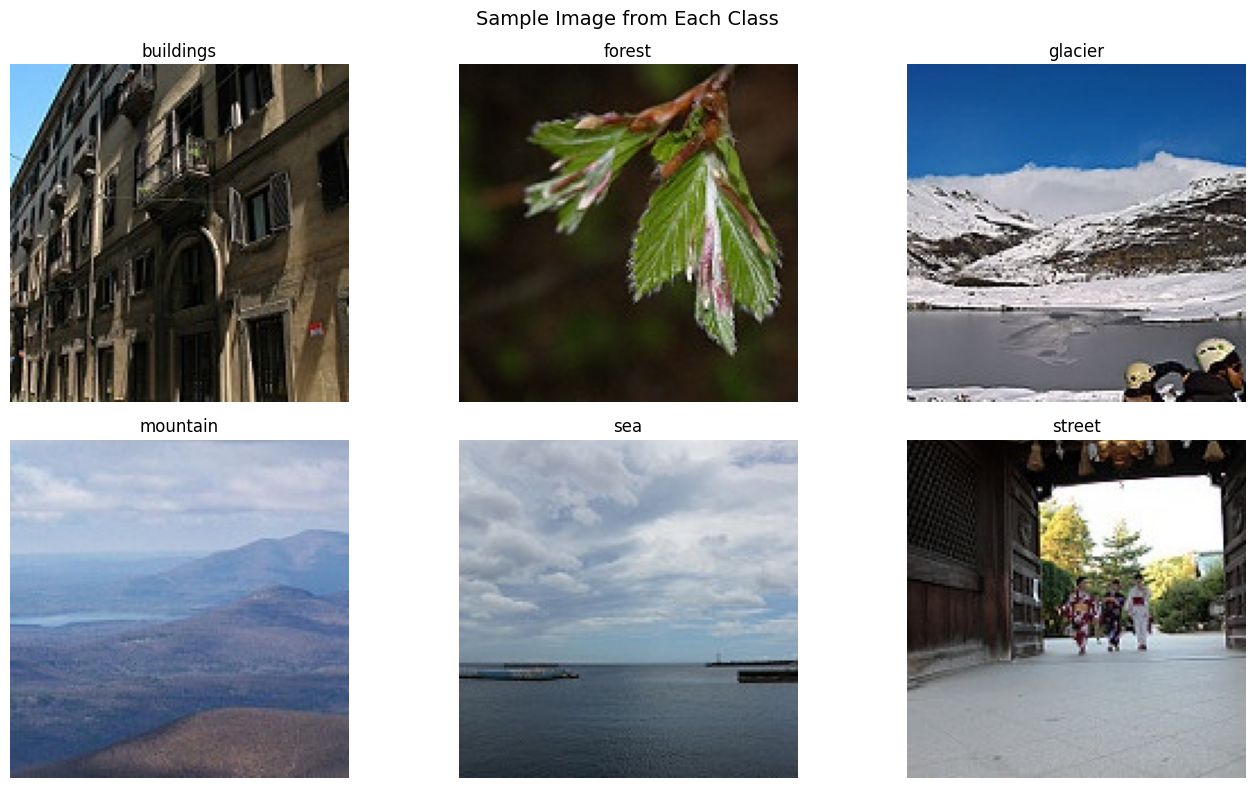

In [ ]:
plt.figure(figsize=(14, 8))
for idx, cls in enumerate(class_names):
    cls_path = os.path.join(train_path, cls)
    img_file = os.listdir(cls_path)[0]
    img = plt.imread(os.path.join(cls_path, img_file))
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.suptitle("Sample Image from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

##Visualize Augmented Images

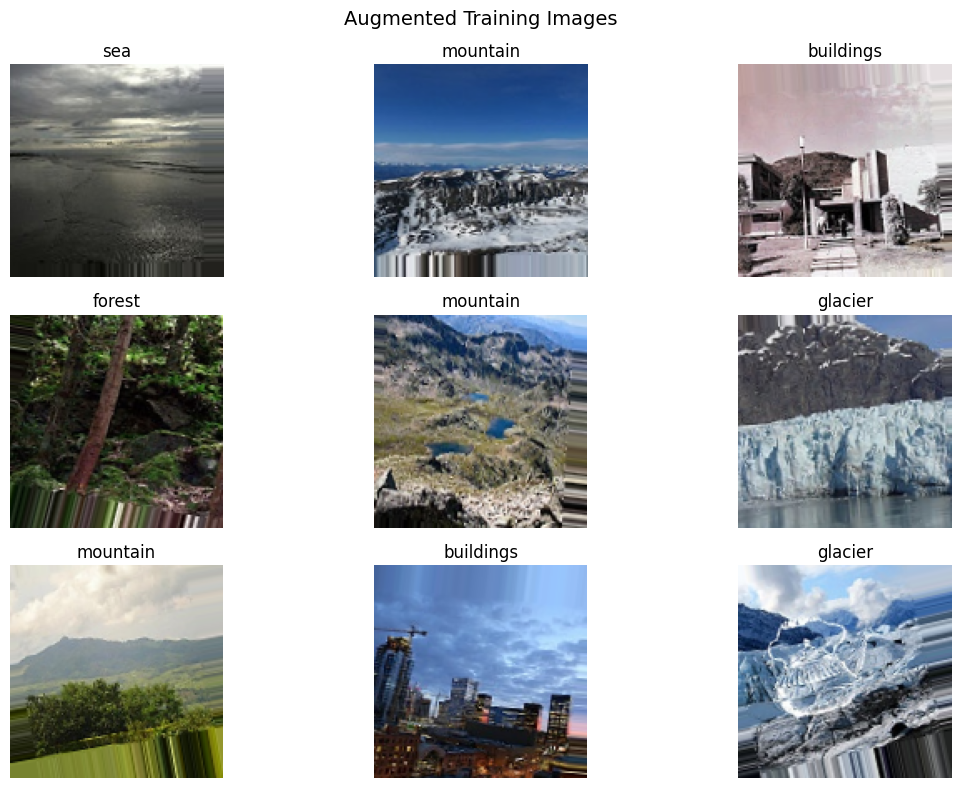

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")
plt.suptitle("Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.show()

##Build Baseline CNN Model

In [ ]:
# ✅ Exactly 3 Conv layers + 3 FC layers as required by assignment
baseline_model = Sequential([

    # Conv Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    # Conv Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Conv Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    # 3 Fully Connected Layers
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,574 (25.02 MB)

 Trainable params: 6,557,574 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

##Compile & Train Baseline Model

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

baseline_time = time.time() - start
print(f"\nBaseline training time: {baseline_time:.2f} seconds")

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 3274s 9s/step - accuracy: 0.5418 - loss: 1.1306 - val_accuracy: 0.6266 - val_loss: 1.0029
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 278ms/step - accuracy: 0.6638 - loss: 0.8678 - val_accuracy: 0.7272 - val_loss: 0.7357
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.7224 - loss: 0.7513 - val_accuracy: 0.7639 - val_loss: 0.6391
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 279ms/step - accuracy: 0.7531 - loss: 0.6663 - val_accuracy: 0.8078 - val_loss: 0.5314
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 279ms/step - accuracy: 0.7835 - loss: 0.5990 - val_accuracy: 0.7750 - val_loss: 0.6122
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.7930 - loss: 0.5624 - val_accuracy: 0.8306 - val_loss: 0.4628
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.8010 - loss: 0.5462 - val_accuracy: 0.8224 - val_loss: 0.5127
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.8190 - loss: 0

##Plot Baseline Accuracy & Loss

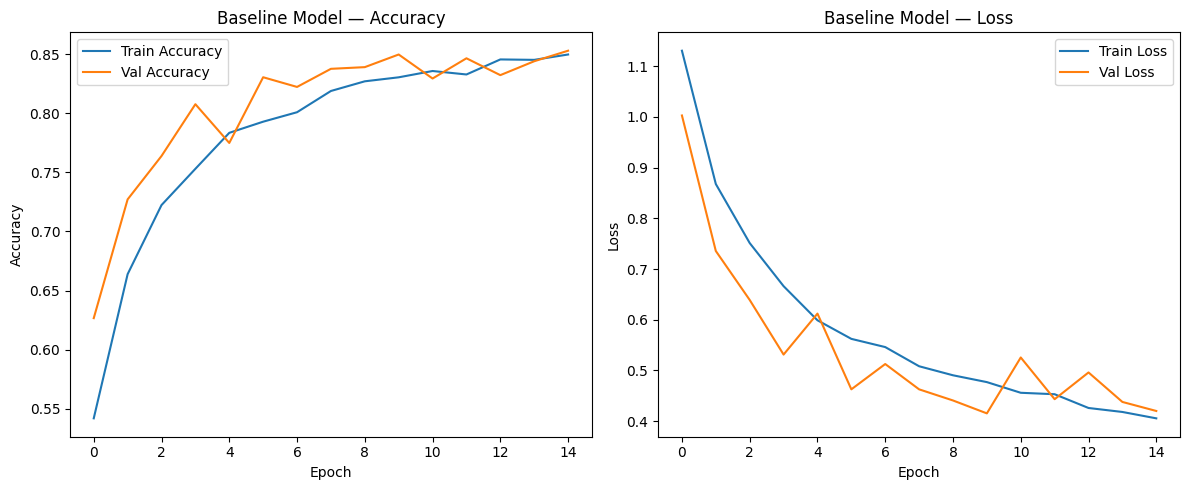

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Baseline Model — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Baseline Model — Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

##Evaluate Baseline Model

In [ ]:
loss, accuracy = baseline_model.evaluate(test_generator)
print(f"Baseline Test Accuracy: {accuracy:.4f}")
print(f"Baseline Test Loss:     {loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 623s 7s/step - accuracy: 0.8427 - loss: 0.4348
Baseline Test Accuracy: 0.8427
Baseline Test Loss:     0.4348


##Classification Report + Confusion Matrix (Baseline)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step
Classification Report — Baseline Model
              precision    recall  f1-score   support

   buildings       0.75      0.91      0.82       437
      forest       0.95      0.96      0.96       474
     glacier       0.83      0.76      0.79       553
    mountain       0.77      0.83      0.80       525
         sea       0.87      0.82      0.84       510
      street       0.91      0.79      0.85       501

    accuracy                           0.84      3000
   macro avg       0.85      0.85      0.84      3000
weighted avg       0.85      0.84      0.84      3000



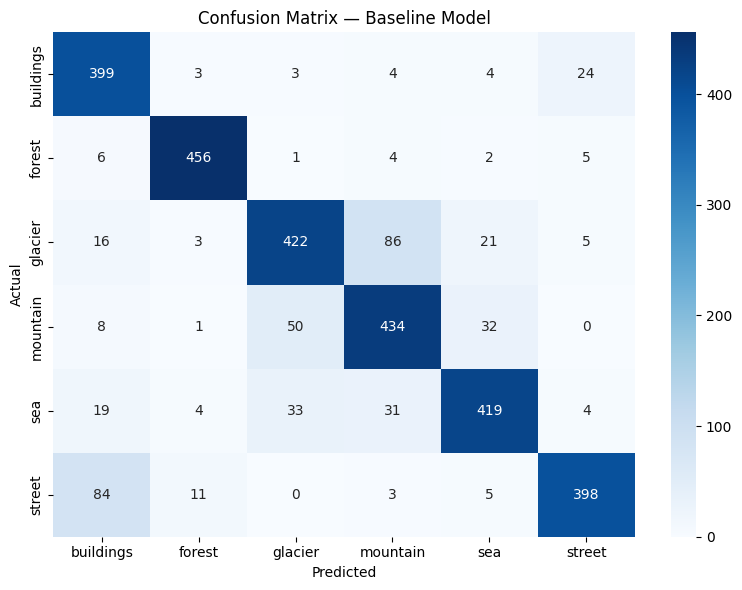

In [ ]:
test_generator.reset()
predictions = baseline_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Classification Report — Baseline Model")
print(classification_report(y_true, y_pred, target_names=class_names))

# ✅ FIXED: Confusion matrix with class name labels
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

##Sample Inference on Test Images (Baseline)

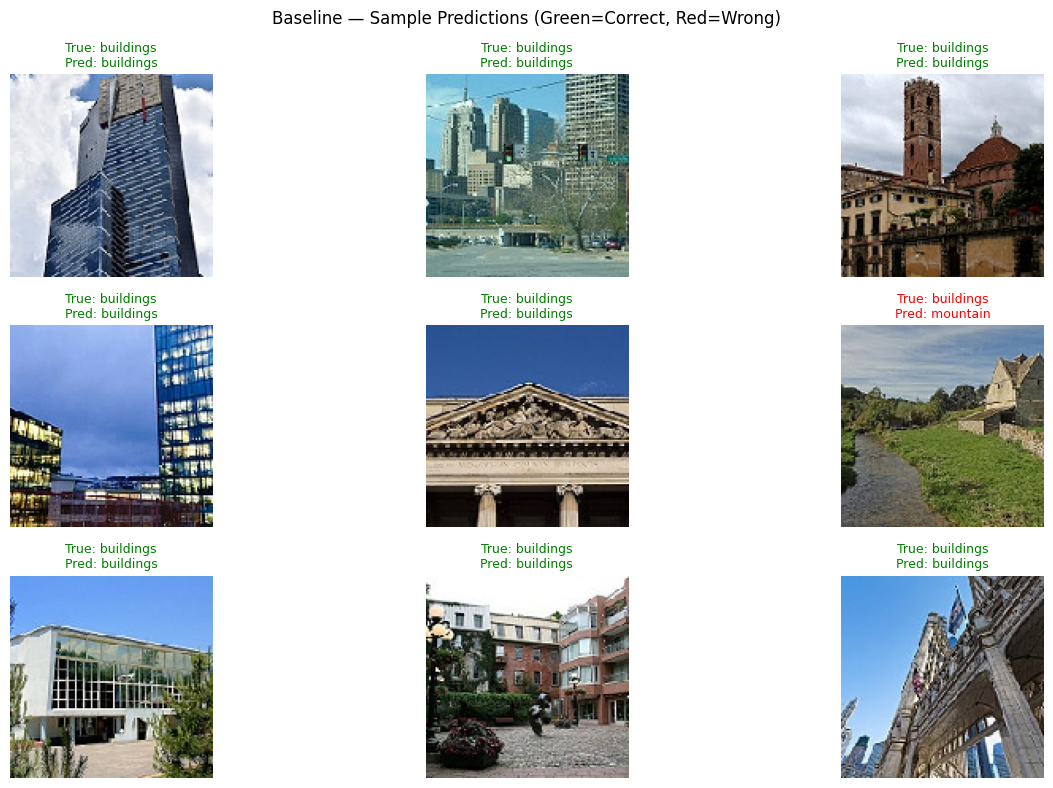

In [ ]:
test_generator.reset()
images, labels = next(test_generator)

plt.figure(figsize=(14, 8))
for i in range(9):
    img = images[i]
    pred = baseline_model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = class_names[np.argmax(pred)]
    true_class = class_names[np.argmax(labels[i])]
    color = 'green' if pred_class == true_class else 'red'

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_class}\nPred: {pred_class}", color=color, fontsize=9)
    plt.axis("off")

plt.suptitle("Baseline — Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

##Build Deeper CNN with Regularization

In [ ]:
# ✅ Deeper model: 5 Conv layers (more than double baseline's 3)
# with BatchNormalization and Dropout as required
deep_model = Sequential([

    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 5
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 5,932,358 (22.63 MB)

 Trainable params: 5,930,374 (22.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

##Train Deeper Model with Adam

In [ ]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

deep_time = time.time() - start
print(f"\nDeeper model (Adam) training time: {deep_time:.2f} seconds")

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 317ms/step - accuracy: 0.5289 - loss: 1.2639 - val_accuracy: 0.4005 - val_loss: 1.6983
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.6308 - loss: 0.9839 - val_accuracy: 0.6919 - val_loss: 0.8185
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 280ms/step - accuracy: 0.6770 - loss: 0.8753 - val_accuracy: 0.7817 - val_loss: 0.6216
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.7098 - loss: 0.7953 - val_accuracy: 0.7757 - val_loss: 0.6227
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - accuracy: 0.7278 - loss: 0.7470 - val_accuracy: 0.7621 - val_loss: 0.6814

Deeper model (Adam) training time: 564.33 seconds


##Plot Deep Model Accuracy & Loss

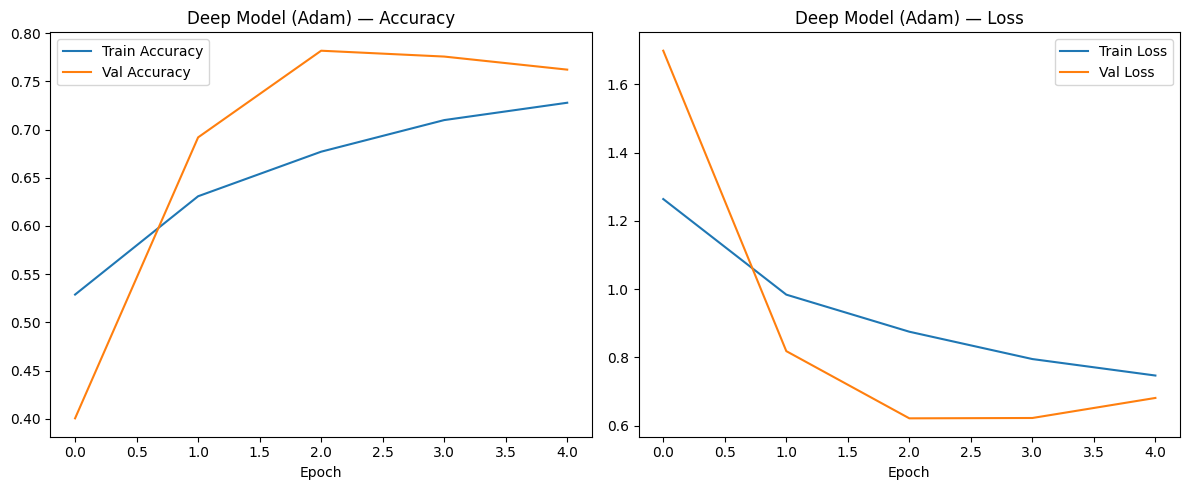

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Deep Model (Adam) — Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Deep Model (Adam) — Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

##Train Deep Model with SGD (Comparison)

In [ ]:
# ✅ FIXED: Clone and train separately with same callbacks for fair comparison
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_sgd = sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]   # ✅ FIXED: added early stopping here too
)

sgd_time = time.time() - start
print(f"\nDeeper model (SGD) training time: {sgd_time:.2f} seconds")

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 115s 305ms/step - accuracy: 0.5322 - loss: 1.2408 - val_accuracy: 0.4447 - val_loss: 1.5474
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 291ms/step - accuracy: 0.6368 - loss: 0.9485 - val_accuracy: 0.6762 - val_loss: 0.8669
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.6751 - loss: 0.8567 - val_accuracy: 0.7618 - val_loss: 0.6654
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - accuracy: 0.7180 - loss: 0.7648 - val_accuracy: 0.5535 - val_loss: 1.3070
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.7444 - loss: 0.7128 - val_accuracy: 0.7265 - val_loss: 0.7418

Deeper model (SGD) training time: 562.12 seconds


##Adam vs SGD Comparison Plot

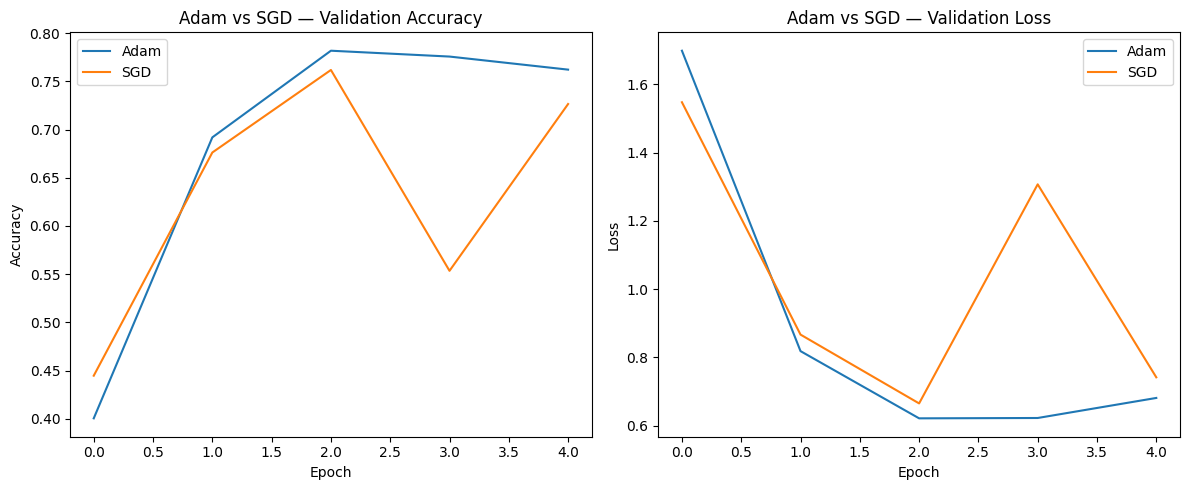

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.legend()
plt.title("Adam vs SGD — Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.legend()
plt.title("Adam vs SGD — Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

##Ablation Study (Remove Dropout)

In [ ]:
# ✅ Required by assignment: remove one component and compare
ablation_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(), MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu', padding='same'),
    BatchNormalization(), MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    # Dropout REMOVED for ablation study
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

ablation_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 114s 299ms/step - accuracy: 0.6519 - loss: 0.9253 - val_accuracy: 0.3010 - val_loss: 1.9920
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 295ms/step - accuracy: 0.7533 - loss: 0.6736 - val_accuracy: 0.7668 - val_loss: 0.6714
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 288ms/step - accuracy: 0.7788 - loss: 0.6008 - val_accuracy: 0.8131 - val_loss: 0.5378
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - accuracy: 0.8037 - loss: 0.5381 - val_accuracy: 0.7914 - val_loss: 0.5852
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 101s 288ms/step - accuracy: 0.8209 - loss: 0.4901 - val_accuracy: 0.7643 - val_loss: 0.6786


##Ablation Comparison Plot

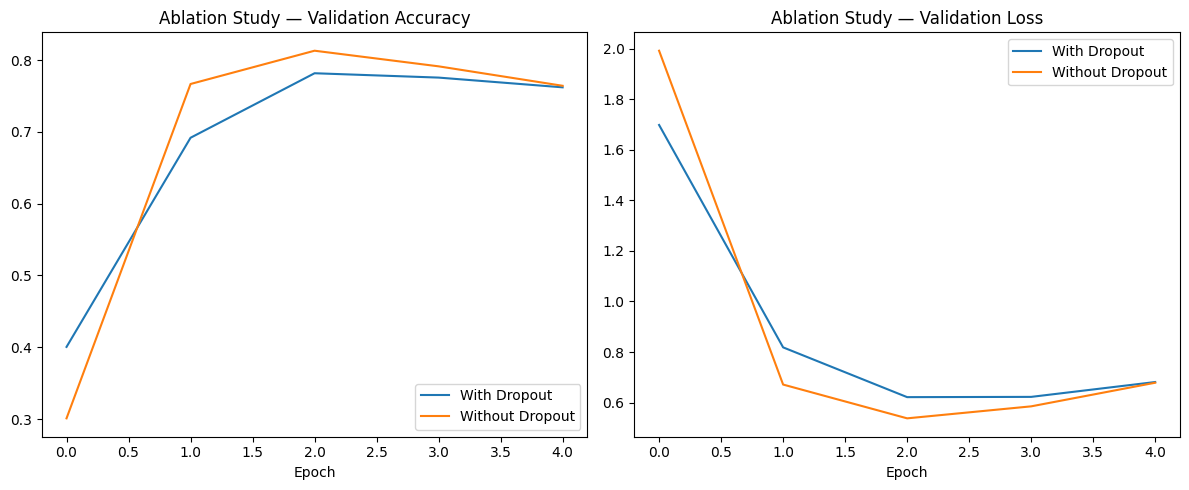

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deep.history['val_accuracy'], label='With Dropout')
plt.plot(history_ablation.history['val_accuracy'], label='Without Dropout')
plt.legend()
plt.title("Ablation Study — Validation Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(history_deep.history['val_loss'], label='With Dropout')
plt.plot(history_ablation.history['val_loss'], label='Without Dropout')
plt.legend()
plt.title("Ablation Study — Validation Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

##Evaluate Deep Model & Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.4057 - loss: 1.6652
Deep Model Test Accuracy: 0.4057
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step
              precision    recall  f1-score   support

   buildings       0.00      0.00      0.00       437
      forest       0.78      0.73      0.76       474
     glacier       0.58      0.21      0.31       553
    mountain       0.36      0.75      0.49       525
         sea       0.28      0.66      0.39       510
      street       0.74      0.05      0.09       501

    accuracy                           0.41      3000
   macro avg       0.46      0.40      0.34      3000
weighted avg       0.46      0.41      0.34      3000



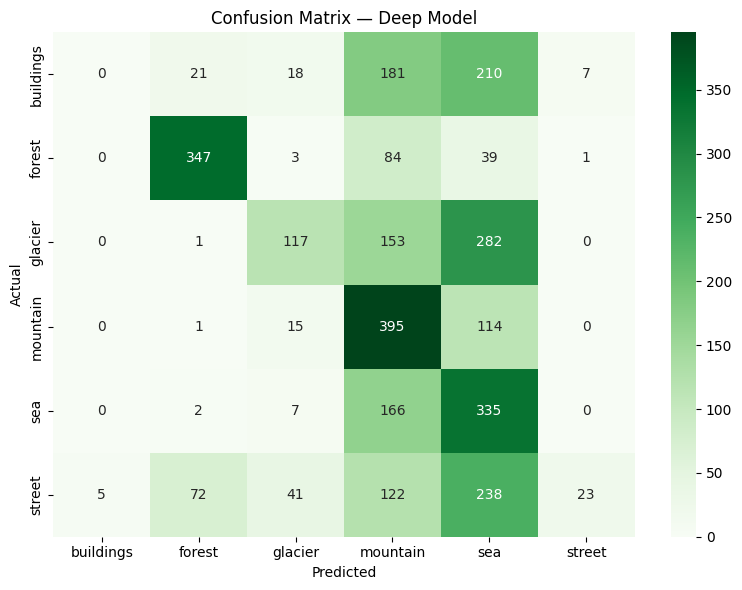

In [ ]:
test_generator.reset()
loss_d, acc_d = deep_model.evaluate(test_generator)
print(f"Deep Model Test Accuracy: {acc_d:.4f}")

test_generator.reset()
preds_deep = deep_model.predict(test_generator)
y_pred_deep = np.argmax(preds_deep, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_deep, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Deep Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

##Training Time Comparison Summary

In [ ]:
print("=" * 45)
print("       Model Training Time Summary")
print("=" * 45)
print(f"  Baseline CNN (Adam):   {baseline_time:.2f} sec")
print(f"  Deep CNN (Adam):       {deep_time:.2f} sec")
print(f"  Deep CNN (SGD):        {sgd_time:.2f} sec")
print("=" * 45)

       Model Training Time Summary
  Baseline CNN (Adam):   4753.38 sec
  Deep CNN (Adam):       564.33 sec
  Deep CNN (SGD):        562.12 sec


##Part B: Load MobileNetV2 (Transfer Learning)

In [ ]:
# ✅ FIXED: Use preprocess_input for MobileNetV2 instead of simple rescale

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ✅ correct preprocessing
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

transfer_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

transfer_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# MobileNetV2 recommended input: 96x96 minimum, 128 works fine
transfer_train_gen = transfer_train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

transfer_val_gen = transfer_val_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

transfer_test_gen = transfer_test_datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load MobileNetV2 with frozen base
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False  # Freeze for feature extraction phase

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Build Transfer Learning Model

In [ ]:
transfer_model = Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Train Transfer Model (Feature Extraction)

In [ ]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 155s 363ms/step - accuracy: 0.8321 - loss: 0.4692 - val_accuracy: 0.9112 - val_loss: 0.2511
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.8750 - loss: 0.3443 - val_accuracy: 0.9112 - val_loss: 0.2471
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.8846 - loss: 0.3140 - val_accuracy: 0.9080 - val_loss: 0.2548
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 279ms/step - accuracy: 0.8882 - loss: 0.3068 - val_accuracy: 0.9130 - val_loss: 0.2436
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.8892 - loss: 0.2936 - val_accuracy: 0.9173 - val_loss: 0.2358
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.8965 - loss: 0.2794 - val_accuracy: 0.9123 - val_loss: 0.2440
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.8947 - loss: 0.2798 - val_accuracy: 0.9101 - val_loss: 0.2511
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.8997 - loss:

##Fine-Tuning (Unfreeze Base)

In [ ]:
# ✅ Unfreeze last 30 layers only for controlled fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# ✅ FIXED: Use very low learning rate to avoid catastrophic forgetting
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=10,
    callbacks=[early_stop]   # ✅ FIXED: added early stopping
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 130s 322ms/step - accuracy: 0.8188 - loss: 0.5123 - val_accuracy: 0.9133 - val_loss: 0.2473
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.8695 - loss: 0.3695 - val_accuracy: 0.9183 - val_loss: 0.2429
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 285ms/step - accuracy: 0.8783 - loss: 0.3328 - val_accuracy: 0.9165 - val_loss: 0.2436
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.8869 - loss: 0.3213 - val_accuracy: 0.9190 - val_loss: 0.2399
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.8897 - loss: 0.3043 - val_accuracy: 0.9173 - val_loss: 0.2395


##Evaluate Transfer Model & Plot

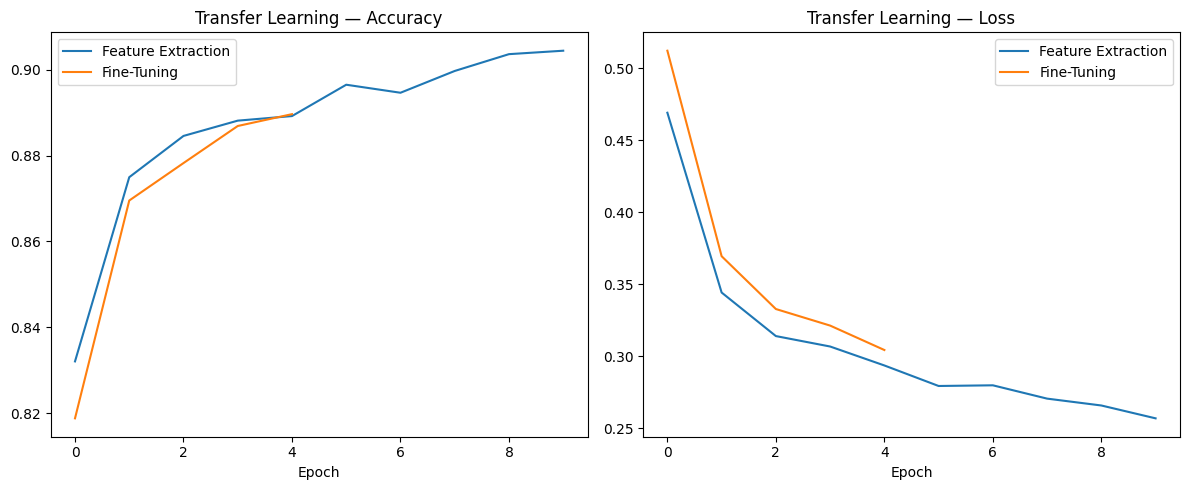

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 233ms/step - accuracy: 0.9163 - loss: 0.2330

Transfer Learning Test Accuracy: 0.9163


In [ ]:
# Plot fine-tuning curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Feature Extraction')
plt.plot(fine_tune_history.history['accuracy'], label='Fine-Tuning')
plt.legend()
plt.title("Transfer Learning — Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Feature Extraction')
plt.plot(fine_tune_history.history['loss'], label='Fine-Tuning')
plt.legend()
plt.title("Transfer Learning — Loss")
plt.xlabel("Epoch")

plt.tight_layout()
plt.show()

# Evaluate on test set
transfer_test_gen.reset()
loss_t, acc_t = transfer_model.evaluate(transfer_test_gen)
print(f"\nTransfer Learning Test Accuracy: {acc_t:.4f}")

##Final Comparison: All Models

94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step
Classification Report — Transfer Learning Model
              precision    recall  f1-score   support

   buildings       0.92      0.92      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.83      0.86       553
    mountain       0.83      0.89      0.86       525
         sea       0.96      0.95      0.95       510
      street       0.93      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



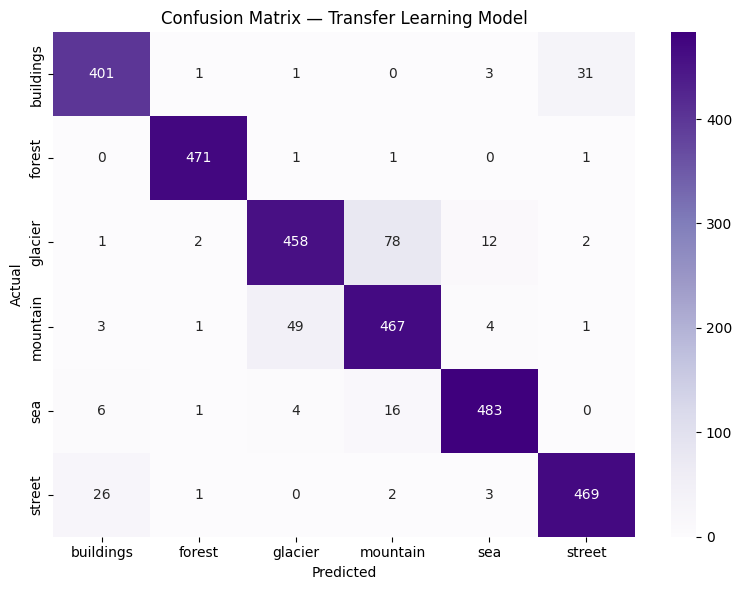


         Final Model Accuracy Comparison
  Baseline CNN:          84.27%
  Deep CNN (Adam):       40.57%
  Transfer Learning:     91.63%


In [ ]:
transfer_test_gen.reset()
preds_t = transfer_model.predict(transfer_test_gen)
y_pred_t = np.argmax(preds_t, axis=1)
y_true_t = transfer_test_gen.classes

print("Classification Report — Transfer Learning Model")
print(classification_report(y_true_t, y_pred_t, target_names=class_names))

cm_t = confusion_matrix(y_true_t, y_pred_t)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Transfer Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Final accuracy comparison table
print("\n" + "=" * 50)
print("         Final Model Accuracy Comparison")
print("=" * 50)
test_generator.reset()
_, acc_b = baseline_model.evaluate(test_generator, verbose=0)
test_generator.reset()
_, acc_d = deep_model.evaluate(test_generator, verbose=0)
print(f"  Baseline CNN:          {acc_b*100:.2f}%")
print(f"  Deep CNN (Adam):       {acc_d*100:.2f}%")
print(f"  Transfer Learning:     {acc_t*100:.2f}%")
print("=" * 50)